# Padel Stroke Classification from Skeletons (RTMO + ST-GCN)

This notebook implements skeleton-based padel stroke classification using pose estimation on player bounding boxes and fine-tuned ST-GCN for action recognition. We extract RTMO keypoints from cropped bounding boxes, apply data augmentation, and train a temporal graph convolutional network.

## Roadmap
1. **Setup & Imports** – Configure environment and import necessary libraries
2. **Dataset Exploration** – Analyze stroke categories and enable class filtering/merging
3. **Pose Extraction from Bounding Boxes** – Extract RTMO keypoints using bbox crops, filter to single person
4. **ST-GCN Model Architecture** – Implement ST-GCN from scratch (no mmaction dependency)
5. **Data Augmentation** – Horizontal flips, scaling, and rotations for skeleton data
6. **Dataset & DataLoader** – PyTorch dataset with augmentation pipeline
7. **Fine-tuning** – Load pre-trained ST-GCN weights and fine-tune on padel strokes
8. **Evaluation** – Metrics, confusion matrix, and model export

In [1]:
# Environment check and dependency installation
import sys
if 'google.colab' in sys.modules:
    print("Installing packages")
    %pip install -q torch torchvision torchaudio rtmlib opencv-python pandas numpy scikit-learn
else:
    print('✓ Using local environment (ensure torch, rtmlib, opencv-python, pandas, numpy, scikit-learn are installed)')

✓ Using local environment (ensure torch, rtmlib, opencv-python, pandas, numpy, scikit-learn are installed)


## 1. Setup & Imports

In [2]:
import json
import urllib.request
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import random

import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm.auto import tqdm
from rtmlib import RTMO
from collections import Counter

# Path configuration
DATASET_ROOT = Path('../dataset').resolve()
BBOX_CSV = DATASET_ROOT / 'bboxes.csv'
ARTIFACTS_ROOT = Path('../artifacts')
POSE_CACHE = ARTIFACTS_ROOT / 'poses_bbox'
SKELETON_CACHE = ARTIFACTS_ROOT / 'skeletons_bbox'
PRETRAINED_DIR = ARTIFACTS_ROOT / 'pretrained'

# Create directories
for path in [POSE_CACHE, SKELETON_CACHE, PRETRAINED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# For deterministic behavior (may impact performance)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Random seed: {SEED}')

Using device: mps
Random seed: 42


Samples per stroke class:
stroke
Backhand_Volley    42
Forehand_Volley    39
Smash              39
Backhand           36
Forehand           33
Vibora             24
Lob                21
Bandeja             8
Contrapared         3
Dropshot            1
Name: count, dtype: int64

Total samples: 246


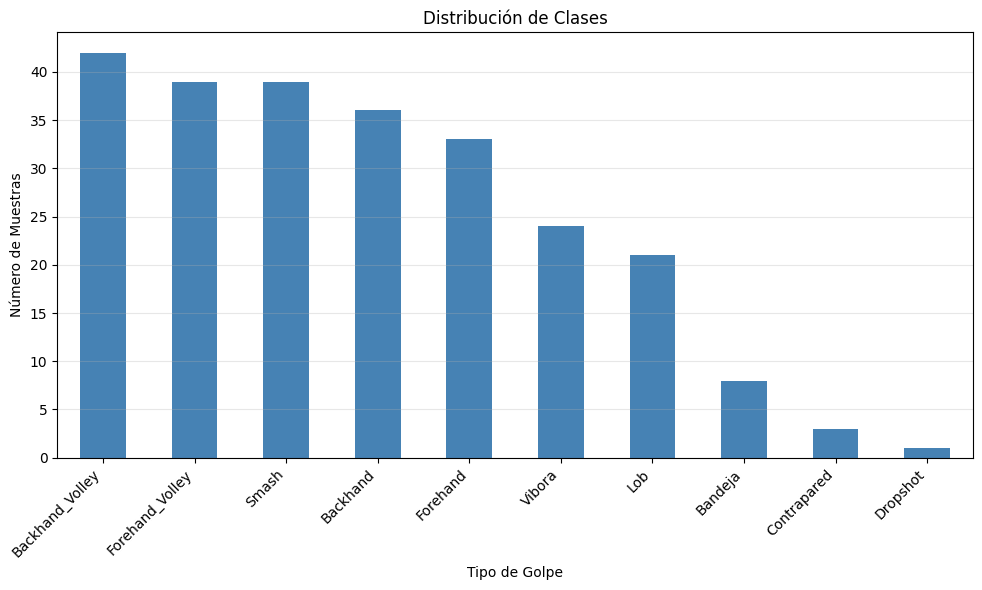

In [3]:
# Load bboxes and count samples per class
bboxes_df = pd.read_csv(BBOX_CSV)
bboxes_df['stroke'] = bboxes_df['video'].apply(lambda x: Path(x).parent.name)
bboxes_df['video_name'] = bboxes_df['video'].apply(lambda x: Path(x).name)

# Count samples per class
class_counts = bboxes_df['stroke'].value_counts().sort_values(ascending=False)
print("Samples per stroke class:")
print(class_counts)
print(f"\nTotal samples: {len(bboxes_df)}")



fig, ax = plt.subplots(figsize=(10, 6))
class_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Tipo de Golpe')
ax.set_ylabel('Número de Muestras')
ax.set_title('Distribución de Clases')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Class Filtering & Merging (Optional)

Use the ClassFilter utility to experiment with different class combinations.

In [4]:
# Class filtering and merging utility
class ClassFilter:
    """Utility to filter or merge stroke classes for experimentation."""
    
    def __init__(self, df: pd.DataFrame):
        self.original_df = df.copy()
        self.df = df.copy()
        
    def filter_classes(self, classes_to_keep: List[str]) -> 'ClassFilter':
        """Keep only specified classes."""
        self.df = self.original_df[self.original_df['stroke'].isin(classes_to_keep)].copy()
        print(f"Filtered to {len(self.df)} samples across {len(classes_to_keep)} classes")
        return self
    
    def merge_classes(self, merge_map: Dict[str, str]) -> 'ClassFilter':
        """Merge classes according to mapping."""
        # Keep original stroke name in a separate column for file path lookup
        self.df['original_stroke'] = self.df['stroke']
        self.df['stroke'] = self.df['stroke'].map(lambda x: merge_map.get(x, x))
        print(f"After merging: {self.df['stroke'].nunique()} unique classes")
        return self
    
    def min_samples(self, min_count: int) -> 'ClassFilter':
        """Keep only classes with at least min_count samples."""
        counts = self.df['stroke'].value_counts()
        valid_classes = counts[counts >= min_count].index.tolist()
        self.df = self.df[self.df['stroke'].isin(valid_classes)].copy()
        print(f"Classes with >={min_count} samples: {len(valid_classes)}")
        return self
    
    def get_df(self) -> pd.DataFrame:
        """Return filtered/merged dataframe."""
        return self.df.copy()

# Apply filtering and merging
class_filter = ClassFilter(bboxes_df)

# Merge Vibora and Bandeja into a single class
merge_map = {
    'Vibora': 'Vibora_Bandeja',
    'Bandeja': 'Vibora_Bandeja'
}

filtered_df = (class_filter
               .merge_classes(merge_map)
               .min_samples(10)
               .get_df())

# Remove Lob class
filtered_df = filtered_df[filtered_df['stroke'] != 'Lob'].copy()

print(f"\nFinal dataset: {len(filtered_df)} samples, {filtered_df['stroke'].nunique()} classes")
print(filtered_df['stroke'].value_counts())

After merging: 9 unique classes
Classes with >=10 samples: 7

Final dataset: 221 samples, 6 classes
stroke
Backhand_Volley    42
Forehand_Volley    39
Smash              39
Backhand           36
Forehand           33
Vibora_Bandeja     32
Name: count, dtype: int64


## 3. Pose Extraction from Bounding Boxes

Extract RTMO keypoints using the bounding box regions from `bboxes.csv`. This focuses pose estimation on the striking player, and we filter to keep only the person with highest confidence.

In [5]:
# Initialize RTMO detector (singleton pattern)
_RTMO_INSTANCE = None

def get_rtmo_detector():
    """Get or create RTMO detector instance."""
    global _RTMO_INSTANCE
    if _RTMO_INSTANCE is None:
        _RTMO_INSTANCE = RTMO(
            onnx_model='https://download.openmmlab.com/mmpose/v1/projects/rtmo/onnx_sdk/rtmo-s_8xb32-600e_body7-640x640-dac2bf74_20231211.zip',
            backend='onnxruntime',
            device=device,
            model_input_size=(640, 640),
            score_thr=0.3,  # Slightly higher threshold for better quality
            nms_thr=0.45
        )
    return _RTMO_INSTANCE


def extract_pose_from_bbox(video_path: Path, bbox: Dict, overwrite: bool = False) -> Optional[Path]:
    """
    Extract pose keypoints from video using bounding box crop.
    
    Args:
        video_path: Path to video file
        bbox: Dict with keys 'x', 'y', 'width', 'height' (in percentage of frame)
        overwrite: Whether to overwrite existing cache
        
    Returns:
        Path to cached JSON file with keypoints, or None if extraction fails
    """
    output_path = POSE_CACHE / f"{video_path.stem}.json"
    
    if output_path.exists() and not overwrite:
        return output_path
    
    rtmo = get_rtmo_detector()
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        print(f"Error opening video: {video_path}")
        return None
    
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Convert bbox percentages to pixels
    x1 = int((bbox['x'] / 100) * frame_width)
    y1 = int((bbox['y'] / 100) * frame_height)
    x2 = int(((bbox['x'] + bbox['width']) / 100) * frame_width)
    y2 = int(((bbox['y'] + bbox['height']) / 100) * frame_height)
    
    # Ensure bbox is within frame bounds
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(frame_width, x2), min(frame_height, y2)
    
    frames_data = []
    frame_idx = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # Crop frame to bounding box
        cropped_frame = frame[y1:y2, x1:x2]
        
        if cropped_frame.size == 0:
            frames_data.append({'keypoints': [], 'scores': [], 'frame_idx': frame_idx})
            frame_idx += 1
            continue
        
        # Run pose estimation on cropped frame
        keypoints, scores = rtmo(cropped_frame)
        
        # Filter to single person with highest confidence
        if keypoints is not None and len(keypoints) > 0:
            # Compute average confidence per person
            avg_scores = np.mean(scores, axis=1)
            best_person_idx = np.argmax(avg_scores)
            
            # Adjust keypoint coordinates back to full frame coordinates
            kp = keypoints[best_person_idx].copy()
            kp[:, 0] += x1  # Add x offset
            kp[:, 1] += y1  # Add y offset
            
            frames_data.append({
                'keypoints': kp.tolist(),
                'scores': scores[best_person_idx].tolist(),
                'frame_idx': frame_idx,
                'bbox': {'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2}
            })
        else:
            frames_data.append({'keypoints': [], 'scores': [], 'frame_idx': frame_idx})
        
        frame_idx += 1
    
    cap.release()
    
    # Save to JSON
    payload = {
        'video': video_path.name,
        'fps': fps,
        'frame_width': frame_width,
        'frame_height': frame_height,
        'bbox_percent': bbox,
        'frames': frames_data
    }
    
    output_path.write_text(json.dumps(payload, indent=2))
    return output_path


print("RTMO pose extraction utilities loaded")

RTMO pose extraction utilities loaded


In [6]:
# Batch extract poses for all videos in filtered dataset
def batch_extract_poses(df: pd.DataFrame, overwrite: bool = False) -> pd.DataFrame:
    """Extract poses for all videos and create manifest."""
    manifest = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting poses"):
        # Use original_stroke if available (for merged classes), otherwise use stroke
        stroke_dir = row.get('original_stroke', row['stroke'])
        video_path = DATASET_ROOT / stroke_dir / row['video_name']
        
        if not video_path.exists():
            print(f"Warning: Video not found: {video_path}")
            continue
        
        bbox = {
            'x': row['x'],
            'y': row['y'],
            'width': row['width'],
            'height': row['height']
        }
        
        pose_path = extract_pose_from_bbox(video_path, bbox, overwrite)
        
        if pose_path:
            manifest.append({
                'stroke': row['stroke'],
                'video_name': row['video_name'],
                'pose_path': str(pose_path)
            })
    
    manifest_df = pd.DataFrame(manifest)
    manifest_df.to_csv(POSE_CACHE / 'pose_manifest.csv', index=False)
    return manifest_df


# Extract poses (this may take a while on first run)
pose_manifest = batch_extract_poses(filtered_df, overwrite=False)

# Load and apply blacklist
blacklist_path = POSE_CACHE / 'blacklist.csv'
if blacklist_path.exists():
    blacklist_df = pd.read_csv(blacklist_path)
    blacklisted_videos = set(blacklist_df['video_name'].tolist())
    original_count = len(pose_manifest)
    pose_manifest = pose_manifest[~pose_manifest['video_name'].isin(blacklisted_videos)].copy()
    removed_count = original_count - len(pose_manifest)
    print(f"\n✓ Blacklist applied: {removed_count} videos excluded")
    print(f"  Total blacklisted: {len(blacklisted_videos)}")
    print(f"  Remaining videos: {len(pose_manifest)}")
else:
    print(f"\nNo blacklist found at {blacklist_path}")
    print(f"Extracted poses for {len(pose_manifest)} videos")

pose_manifest['stroke'].value_counts()

Extracting poses:   0%|          | 0/221 [00:00<?, ?it/s]


✓ Blacklist applied: 22 videos excluded
  Total blacklisted: 22
  Remaining videos: 199


stroke
Backhand_Volley    38
Backhand           35
Smash              34
Forehand           31
Forehand_Volley    31
Vibora_Bandeja     30
Name: count, dtype: int64

Analyzing frame counts from extracted poses...

Frame count statistics:
  Min: 7
  Max: 26
  Mean: 16.1
  Median: 16.0
  Std: 3.4
  25th percentile: 13.0
  75th percentile: 19.0

Recommended clip_len (90th percentile): 20


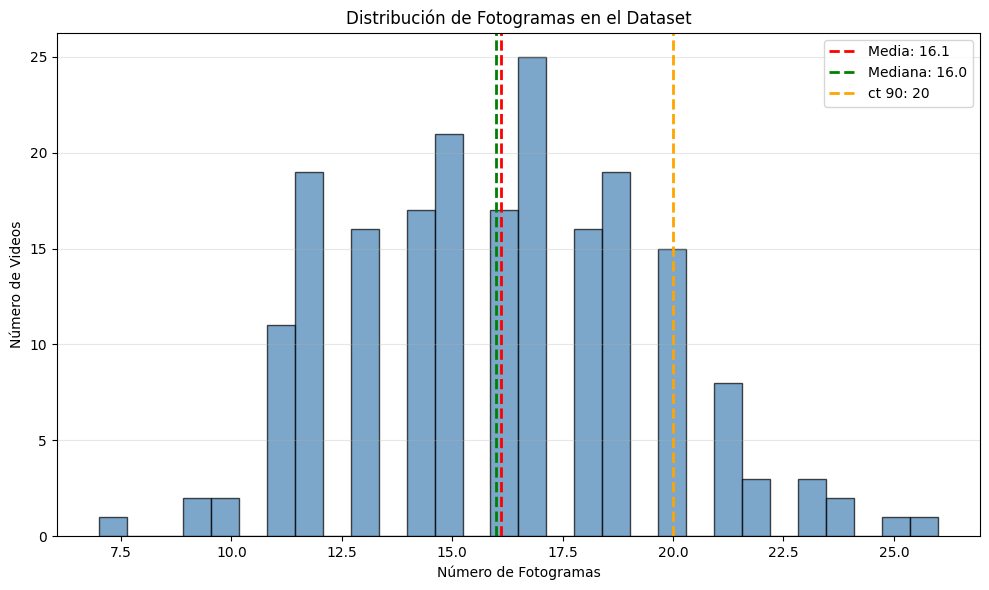


Using CLIP_LEN = 20


In [7]:
# Analyze actual frame counts in the dataset
print("Analyzing frame counts from extracted poses...")

frame_counts = []
for pose_path in pose_manifest['pose_path']:
    with open(pose_path, 'r') as f:
        pose_data = json.load(f)
    frame_counts.append(len(pose_data['frames']))

frame_counts = np.array(frame_counts)

print(f"\nFrame count statistics:")
print(f"  Min: {frame_counts.min()}")
print(f"  Max: {frame_counts.max()}")
print(f"  Mean: {frame_counts.mean():.1f}")
print(f"  Median: {np.median(frame_counts):.1f}")
print(f"  Std: {frame_counts.std():.1f}")
print(f"  25th percentile: {np.percentile(frame_counts, 25):.1f}")
print(f"  75th percentile: {np.percentile(frame_counts, 75):.1f}")

# Recommend clip length
recommended_clip_len = int(np.percentile(frame_counts, 90))
print(f"\nRecommended clip_len (90th percentile): {recommended_clip_len}")

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(frame_counts, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(frame_counts.mean(), color='red', linestyle='--', label=f'Media: {frame_counts.mean():.1f}', linewidth=2)
plt.axvline(np.median(frame_counts), color='green', linestyle='--', label=f'Mediana: {np.median(frame_counts):.1f}', linewidth=2)
plt.axvline(recommended_clip_len, color='orange', linestyle='--', label=f'ct 90: {recommended_clip_len}', linewidth=2)
plt.xlabel('Número de Fotogramas')
plt.ylabel('Número de Videos')
plt.title('Distribución de Fotogramas en el Dataset')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

CLIP_LEN = recommended_clip_len
print(f"\nUsing CLIP_LEN = {CLIP_LEN}")

## 4. ST-GCN Model Architecture

Implement Spatial Temporal Graph Convolutional Network from scratch. ST-GCN models skeleton sequences as graphs where joints are nodes and bones are edges.

In [8]:
# COCO skeleton graph structure (17 keypoints)
# Edges represent bones connecting joints
COCO_EDGES = [
    (0, 1), (0, 2),  # nose to eyes
    (1, 3), (2, 4),  # eyes to ears
    (0, 5), (0, 6),  # nose to shoulders
    (5, 7), (7, 9),  # left arm
    (6, 8), (8, 10), # right arm
    (5, 11), (6, 12), # shoulders to hips
    (11, 13), (13, 15), # left leg
    (12, 14), (14, 16)  # right leg
]

def get_adjacency_matrix(num_nodes: int, edges: List[Tuple[int, int]], self_loops: bool = True):
    """
    Build adjacency matrix for skeleton graph.
    
    Args:
        num_nodes: Number of joints (17 for COCO)
        edges: List of (src, dst) edge tuples
        self_loops: Whether to add self-connections
        
    Returns:
        Adjacency matrix of shape (num_nodes, num_nodes)
    """
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    
    # Add edges (bidirectional)
    for i, j in edges:
        A[i, j] = 1
        A[j, i] = 1
    
    # Add self-loops
    if self_loops:
        A += np.eye(num_nodes)
    
    return A


def normalize_adjacency(A: np.ndarray) -> np.ndarray:
    """Normalize adjacency matrix: D^{-1/2} * A * D^{-1/2}"""
    D = np.sum(A, axis=1)
    D_inv_sqrt = np.power(D, -0.5)
    D_inv_sqrt[np.isinf(D_inv_sqrt)] = 0.
    D_mat = np.diag(D_inv_sqrt)
    return D_mat @ A @ D_mat


# Build and normalize adjacency matrix
A = get_adjacency_matrix(17, COCO_EDGES, self_loops=True)
A_norm = normalize_adjacency(A)

print(f"Adjacency matrix shape: {A.shape}")
print(f"Number of edges: {len(COCO_EDGES)}")

Adjacency matrix shape: (17, 17)
Number of edges: 16


In [9]:
class GraphConvolution(nn.Module):
    """Graph convolution layer for skeleton data."""
    
    def __init__(self, in_channels: int, out_channels: int, A: np.ndarray):
        super().__init__()
        self.A = torch.from_numpy(A.astype(np.float32))
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (N, C, T, V) where V is number of joints
        A = self.A.to(x.device)
        
        # Graph convolution: aggregate features from neighboring nodes
        # x shape: (N, C, T, V)
        N, C, T, V = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()  # (N, T, V, C)
        x = x.view(N * T, V, C)  # (N*T, V, C)
        
        # Matrix multiplication with adjacency
        x = torch.matmul(A, x)  # (N*T, V, C)
        
        x = x.view(N, T, V, C)  # (N, T, V, C)
        x = x.permute(0, 3, 1, 2).contiguous()  # (N, C, T, V)
        
        # 1x1 convolution to mix channels
        x = self.conv(x)
        
        return x


class STGCNBlock(nn.Module):
    """Spatial-Temporal Graph Convolutional Block."""
    
    def __init__(self, in_channels: int, out_channels: int, A: np.ndarray, 
                 stride: int = 1, residual: bool = True):
        super().__init__()
        
        self.gcn = GraphConvolution(in_channels, out_channels, A)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=(9, 1), 
                     padding=(4, 0), stride=(stride, 1)),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(0.5)
        )
        
        self.residual = residual
        if not residual or in_channels != out_channels or stride != 1:
            self.residual_conv = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.residual_conv = nn.Identity()
        
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        res = self.residual_conv(x)
        x = self.gcn(x)
        x = self.tcn(x)
        return self.relu(x + res)


class STGCN(nn.Module):
    """
    Spatial Temporal Graph Convolutional Network for action recognition.
    
    Input shape: (N, C, T, V, M) where:
        N = batch size
        C = number of channels (3 for x, y, confidence)
        T = number of frames
        V = number of joints (17 for COCO)
        M = number of persons (1 in our case)
    """
    
    def __init__(self, num_classes: int, in_channels: int = 3, 
                 A: Optional[np.ndarray] = None, dropout: float = 0.5):
        super().__init__()
        
        if A is None:
            A = get_adjacency_matrix(17, COCO_EDGES, self_loops=True)
            A = normalize_adjacency(A)
        
        self.data_bn = nn.BatchNorm1d(in_channels * 17)
        
        # ST-GCN layers with increasing channels
        self.st_gcn_networks = nn.ModuleList([
            STGCNBlock(in_channels, 64, A, stride=1, residual=False),
            STGCNBlock(64, 64, A, stride=1),
            STGCNBlock(64, 64, A, stride=1),
            STGCNBlock(64, 128, A, stride=2),
            STGCNBlock(128, 128, A, stride=1),
            STGCNBlock(128, 128, A, stride=1),
            STGCNBlock(128, 256, A, stride=2),
            STGCNBlock(256, 256, A, stride=1),
            STGCNBlock(256, 256, A, stride=1),
        ])
        
        # Global pooling and classifier
        self.fc = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Input: (N, C, T, V, M)
        N, C, T, V, M = x.shape
        
        # Average over persons (M dimension)
        x = x.mean(dim=-1)  # (N, C, T, V)
        
        # Batch normalization
        x = x.permute(0, 3, 1, 2).contiguous()  # (N, V, C, T)
        x = x.view(N, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, V, C, T)
        x = x.permute(0, 2, 3, 1).contiguous()  # (N, C, T, V)
        
        # ST-GCN blocks
        for gcn in self.st_gcn_networks:
            x = gcn(x)
        
        # Global average pooling over time and space
        x = F.avg_pool2d(x, x.size()[2:])  # (N, C, 1, 1)
        x = x.view(N, -1)  # (N, C)
        
        # Classifier
        x = self.dropout(x)
        x = self.fc(x)
        
        return x


# Test model instantiation
test_model = STGCN(num_classes=10, in_channels=3, A=A_norm)
test_input = torch.randn(2, 3, 32, 17, 1)  # (batch=2, channels=3, frames=32, joints=17, persons=1)
test_output = test_model(test_input)
print(f"Model output shape: {test_output.shape}")  # Should be (2, 10)
print("Note: Actual clip length will be determined from dataset statistics")
del test_model, test_input, test_output

Model output shape: torch.Size([2, 10])
Note: Actual clip length will be determined from dataset statistics


In [10]:
class SkeletonAugmentation:
    """Data augmentation for skeleton sequences."""
    
    # COCO keypoint pairs for left-right flipping
    COCO_LR_PAIRS = [
        (1, 2), (3, 4),  # eyes and ears
        (5, 6), (7, 8), (9, 10),  # shoulders, elbows, wrists
        (11, 12), (13, 14), (15, 16)  # hips, knees, ankles
    ]
    
    def __init__(self, 
                 flip_prob: float = 0.5,
                 scale_range: Tuple[float, float] = (0.9, 1.1),
                 rotation_range: Tuple[float, float] = (-10, 10),
                 apply_prob: float = 0.5):
        self.flip_prob = flip_prob
        self.scale_range = scale_range
        self.rotation_range = rotation_range
        self.apply_prob = apply_prob
        
    def horizontal_flip(self, keypoints: np.ndarray) -> np.ndarray:
        """
        Flip skeleton horizontally and swap left-right keypoints.
        
        Args:
            keypoints: (C, T, V, M) array where C=3 (x, y, confidence)
        """
        keypoints = keypoints.copy()
        
        # Flip x coordinates (assume normalized to [0, 1] or centered)
        # If coordinates are in pixel space, adjust accordingly
        C, T, V, M = keypoints.shape
        
        # Find the center x coordinate
        valid_mask = keypoints[2] > 0  # confidence > 0
        if valid_mask.any():
            center_x = np.median(keypoints[0][valid_mask])
            keypoints[0] = 2 * center_x - keypoints[0]
        else:
            keypoints[0] = -keypoints[0]
        
        # Swap left-right keypoints
        for left_idx, right_idx in self.COCO_LR_PAIRS:
            keypoints[:, :, [left_idx, right_idx], :] = keypoints[:, :, [right_idx, left_idx], :]
        
        return keypoints
    
    def scale(self, keypoints: np.ndarray, scale_factor: float) -> np.ndarray:
        """
        Scale skeleton by a factor.
        
        Args:
            keypoints: (C, T, V, M) array
            scale_factor: Scaling factor
        """
        keypoints = keypoints.copy()
        
        # Find center of mass
        valid_mask = keypoints[2] > 0
        if valid_mask.any():
            center_x = np.mean(keypoints[0][valid_mask])
            center_y = np.mean(keypoints[1][valid_mask])
            
            # Scale relative to center
            keypoints[0] = center_x + (keypoints[0] - center_x) * scale_factor
            keypoints[1] = center_y + (keypoints[1] - center_y) * scale_factor
        
        return keypoints
    
    def rotate(self, keypoints: np.ndarray, angle_deg: float) -> np.ndarray:
        """
        Rotate skeleton by angle in degrees.
        
        Args:
            keypoints: (C, T, V, M) array
            angle_deg: Rotation angle in degrees
        """
        keypoints = keypoints.copy()
        angle_rad = np.deg2rad(angle_deg)
        
        # Find center of mass
        valid_mask = keypoints[2] > 0
        if not valid_mask.any():
            return keypoints
        
        center_x = np.mean(keypoints[0][valid_mask])
        center_y = np.mean(keypoints[1][valid_mask])
        
        # Rotation matrix
        cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
        
        # Translate to origin
        x_centered = keypoints[0] - center_x
        y_centered = keypoints[1] - center_y
        
        # Rotate
        x_rotated = x_centered * cos_a - y_centered * sin_a
        y_rotated = x_centered * sin_a + y_centered * cos_a
        
        # Translate back
        keypoints[0] = x_rotated + center_x
        keypoints[1] = y_rotated + center_y
        
        return keypoints
    
    def __call__(self, keypoints: np.ndarray, training: bool = True) -> np.ndarray:
        """
        Apply random augmentations.
        
        Args:
            keypoints: (C, T, V, M) array
            training: Whether to apply augmentations
        """
        if not training or np.random.rand() > self.apply_prob:
            return keypoints
        
        # Horizontal flip
        if np.random.rand() < self.flip_prob:
            keypoints = self.horizontal_flip(keypoints)
        
        # Random scaling
        scale_factor = np.random.uniform(*self.scale_range)
        keypoints = self.scale(keypoints, scale_factor)
        
        # Random rotation
        angle = np.random.uniform(*self.rotation_range)
        keypoints = self.rotate(keypoints, angle)
        
        return keypoints


# Test augmentation
test_aug = SkeletonAugmentation()
test_kp = np.random.randn(3, 50, 17, 1)  # (C, T, V, M)
test_kp[2] = np.abs(test_kp[2])  # Confidence scores positive
augmented = test_aug(test_kp, training=True)
print(f"Original shape: {test_kp.shape}, Augmented shape: {augmented.shape}")
del test_aug, test_kp, augmented

Original shape: (3, 50, 17, 1), Augmented shape: (3, 50, 17, 1)


## 6. Dataset & DataLoader

Create train/val splits and PyTorch datasets with augmentation.

In [11]:
class PadelSkeletonDataset(Dataset):
    """PyTorch dataset for skeleton-based stroke classification."""
    
    def __init__(self, 
                 manifest_df: pd.DataFrame,
                 clip_len: int = 64,
                 augmentation: Optional[SkeletonAugmentation] = None,
                 training: bool = True):
        """
        Args:
            manifest_df: DataFrame with columns ['stroke', 'video_name', 'pose_path']
            clip_len: Number of frames to sample
            augmentation: SkeletonAugmentation instance
            training: Whether this is training data
        """
        self.manifest = manifest_df.reset_index(drop=True)
        self.clip_len = clip_len
        self.augmentation = augmentation
        self.training = training
        
        # Create label mapping
        self.labels = sorted(self.manifest['stroke'].unique().tolist())
        self.label_to_idx = {label: idx for idx, label in enumerate(self.labels)}
        
    def __len__(self) -> int:
        return len(self.manifest)
    
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.manifest.iloc[idx]
        
        # Load pose data from JSON
        with open(row['pose_path'], 'r') as f:
            pose_data = json.load(f)
        
        # Extract keypoints and scores from frames
        frames = pose_data['frames']
        keypoints_seq = []
        scores_seq = []
        
        for frame_data in frames:
            if frame_data['keypoints']:
                kp = np.array(frame_data['keypoints'])  # (17, 2)
                sc = np.array(frame_data['scores'])     # (17,)
                keypoints_seq.append(kp)
                scores_seq.append(sc)
        
        if len(keypoints_seq) == 0:
            # No valid keypoints, return zeros
            keypoints = np.zeros((3, self.clip_len, 17, 1), dtype=np.float32)
        else:
            keypoints_seq = np.array(keypoints_seq)  # (T, 17, 2)
            scores_seq = np.array(scores_seq)        # (T, 17)
            
            # Temporal sampling/padding
            T = len(keypoints_seq)
            if T > self.clip_len:
                # Uniformly sample clip_len frames
                indices = np.linspace(0, T - 1, self.clip_len, dtype=int)
                keypoints_seq = keypoints_seq[indices]
                scores_seq = scores_seq[indices]
            elif T < self.clip_len:
                # Pad with last frame
                pad_len = self.clip_len - T
                keypoints_seq = np.concatenate([
                    keypoints_seq,
                    np.repeat(keypoints_seq[-1:], pad_len, axis=0)
                ], axis=0)
                scores_seq = np.concatenate([
                    scores_seq,
                    np.repeat(scores_seq[-1:], pad_len, axis=0)
                ], axis=0)
            
            # Convert to (C, T, V, M) format: channels=3 (x, y, confidence), T=frames, V=joints, M=persons
            x = keypoints_seq[:, :, 0]  # (T, 17)
            y = keypoints_seq[:, :, 1]  # (T, 17)
            conf = scores_seq           # (T, 17)
            
            # Stack and transpose
            keypoints = np.stack([x, y, conf], axis=0)  # (3, T, 17)
            keypoints = keypoints[:, :, :, np.newaxis]  # (3, T, 17, 1) - add person dimension
            
            # Apply augmentation
            if self.augmentation is not None:
                keypoints = self.augmentation(keypoints, training=self.training)
        
        # Convert to tensor
        keypoints = torch.from_numpy(keypoints.astype(np.float32))
        
        # Get label
        label = self.label_to_idx[row['stroke']]
        label = torch.tensor(label, dtype=torch.long)
        
        return {
            'keypoints': keypoints,  # (C, T, V, M)
            'label': label,
            'video_name': row['video_name'],
            'stroke': row['stroke']
        }


print("PadelSkeletonDataset class defined")


PadelSkeletonDataset class defined


In [12]:
# Split dataset into train/val
train_manifest, val_manifest = train_test_split(
    pose_manifest, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=pose_manifest['stroke']
)

print(f"Train samples: {len(train_manifest)}")
print(f"Val samples: {len(val_manifest)}")

# Create datasets with stronger augmentation for small dataset
augmentation = SkeletonAugmentation(
    flip_prob=0.5,
    scale_range=(0.85, 1.15), # More aggressive scaling
    rotation_range=(-15, 15), # More rotation variation
    apply_prob=0.9            # Apply augmentation more frequently
)

train_dataset = PadelSkeletonDataset(
    train_manifest,
    clip_len=CLIP_LEN,  # Use data-driven clip length
    augmentation=augmentation,
    training=True
)

val_dataset = PadelSkeletonDataset(
    val_manifest,
    clip_len=CLIP_LEN,  # Use data-driven clip length
    augmentation=None,
    training=False
)

# Create dataloaders (smaller batch size for small dataset)
train_loader = DataLoader(
    train_dataset,
    batch_size=8,  # Reduced for more frequent gradient updates
    shuffle=True,
    num_workers=0,
    pin_memory=True if device == 'cuda' else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device == 'cuda' else False
)

print(f"\nNumber of classes: {len(train_dataset.labels)}")
print(f"Classes: {train_dataset.labels}")

# Calculate class weights for imbalanced dataset
train_class_counts = Counter(train_manifest['stroke'])
print("\nTraining samples per class:")
for cls in sorted(train_class_counts.keys()):
    print(f"  {cls:20s}: {train_class_counts[cls]}")

Train samples: 159
Val samples: 40

Number of classes: 6
Classes: ['Backhand', 'Backhand_Volley', 'Forehand', 'Forehand_Volley', 'Smash', 'Vibora_Bandeja']

Training samples per class:
  Backhand            : 28
  Backhand_Volley     : 30
  Forehand            : 25
  Forehand_Volley     : 25
  Smash               : 27
  Vibora_Bandeja      : 24


## 7. Fine-tuning ST-GCN

Initialize model with pre-trained weights (if available) and fine-tune on padel strokes.

In [13]:
# Helper function to download and prepare pretrained weights
def download_pretrained_stgcn(force_download: bool = False) -> Optional[Path]:
    """
    Download MMAction ST-GCN weights and convert to our format.
    
    The official NTU-60 checkpoint contains 60 classes. We'll load the backbone
    weights and initialize a new classifier head for our padel classes.
    """
    pretrained_path = PRETRAINED_DIR / 'stgcn_ntu60_backbone.pth'
    
    if pretrained_path.exists() and not force_download:
        print(f"Using cached weights: {pretrained_path}")
        return pretrained_path
    
    print("Downloading ST-GCN NTU-60 checkpoint...")
    url = 'https://download.openmmlab.com/mmaction/skeleton/stgcn/stgcn_80e_ntu60_xsub_keypoint/stgcn_80e_ntu60_xsub_keypoint-e7bb9653.pth'
    
    temp_path = PRETRAINED_DIR / 'stgcn_ntu60_raw.pth'
    
    try:
        urllib.request.urlretrieve(url, temp_path)
        print("Download complete. Converting weights...")
        
        # Load checkpoint
        checkpoint = torch.load(temp_path, map_location='cpu')
        state_dict = checkpoint.get('state_dict', checkpoint)
        
        # Extract only backbone weights (skip classifier head)
        backbone_weights = {}
        for key, value in state_dict.items():
            # Remove 'module.' prefix if present
            key = key.replace('module.', '')
            
            # Remove 'backbone.' prefix if present (from MMAction format)
            if key.startswith('backbone.'):
                key = key.replace('backbone.', '', 1)
            
            # Skip classifier weights (we'll train new head)
            if 'fc' in key or 'cls_head' in key:
                continue
            
            backbone_weights[key] = value
        
        # Save converted weights
        torch.save(backbone_weights, pretrained_path)
        print(f"Saved backbone weights to: {pretrained_path}")
        
        # Clean up temp file
        temp_path.unlink(missing_ok=True)
        
        return pretrained_path
        
    except Exception as e:
        print(f"Error downloading/converting weights: {e}")
        print("Will train from scratch instead.")
        return None


# Download pretrained weights
pretrained_path = download_pretrained_stgcn(force_download=False)

Using cached weights: ../artifacts/pretrained/stgcn_ntu60_backbone.pth


In [14]:
# Training functions
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, batch in enumerate(loader):
        keypoints = batch['keypoints'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(keypoints)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def validate(model, loader, criterion, device):
    """Validate model."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            keypoints = batch['keypoints'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(keypoints)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy, all_preds, all_labels

print("Training functions defined")

Training functions defined


In [15]:
# Initialize model with higher dropout for small dataset
num_classes = len(train_dataset.labels)
model = STGCN(num_classes=num_classes, in_channels=3, A=A_norm, dropout=0.7)  # Increased dropout
model = model.to(device)

# Load pretrained weights if available
if pretrained_path and pretrained_path.exists():
    print("Loading pretrained backbone weights...")
    try:
        pretrained_dict = torch.load(pretrained_path, map_location=device)
        model_dict = model.state_dict()
        
        # Filter out incompatible keys (e.g., classifier)
        pretrained_dict = {k: v for k, v in pretrained_dict.items() 
                          if k in model_dict and v.shape == model_dict[k].shape}
        
        model_dict.update(pretrained_dict)
        model.load_state_dict(model_dict, strict=False)
        print(f"Loaded {len(pretrained_dict)} pretrained layers")
    except Exception as e:
        print(f"Error loading pretrained weights: {e}")
        print("Training from scratch.")
else:
    print("No pretrained weights found. Training from scratch.")

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6:.2f}M")

Loading pretrained backbone weights...
Loaded 93 pretrained layers

Model parameters: 2.59M
Trainable parameters: 2.59M


In [16]:
# Training configuration
num_epochs = 100
learning_rate = 1e-3  # Higher LR with ReduceLROnPlateau scheduler
weight_decay = 5e-4   # Stronger weight decay to reduce overfitting
early_stopping_patience = 15  # Stop if no improvement for 15 epochs
gradient_clip_val = 1.0  # Gradient clipping for stability

# Calculate class weights to handle imbalance
train_labels = [train_dataset.label_to_idx[s] for s in train_manifest['stroke']]
class_counts = torch.bincount(torch.tensor(train_labels))
class_weights = 1.0 / class_counts.float()
class_weights = class_weights / class_weights.sum() * len(class_weights)  # Normalize
class_weights = class_weights.to(device)

print("Class weights:")
for i, label in enumerate(train_dataset.labels):
    print(f"  {label:20s}: {class_weights[i]:.3f}")

# Loss and optimizer with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Learning rate scheduler - reduces LR when validation loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_model_path = SKELETON_CACHE / 'best_stgcn_model.pth'
epochs_without_improvement = 0

print("Training configuration:")
print(f"  Device: {device}")
print("  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Gradient clipping: {gradient_clip_val}")
print(f"  Epochs: {num_epochs}")
print(f"  Early stopping patience: {early_stopping_patience}")


Class weights:
  Backhand            : 0.941
  Backhand_Volley     : 0.878
  Forehand            : 1.054
  Forehand_Volley     : 1.054
  Smash               : 0.976
  Vibora_Bandeja      : 1.098
Training configuration:
  Device: mps
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
  Gradient clipping: 1.0
  Epochs: 100
  Early stopping patience: 15


In [17]:
# Main training loop
print("\nStarting training...\n")

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)
    
    # Update scheduler based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print metrics (TensorFlow/Keras style)
    print(f"  loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - lr: {current_lr:.2e}", end="")
    
    # Save best model and check early stopping
    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'labels': train_dataset.labels,
        }, best_model_path)
        print(" **")
    else:
        epochs_without_improvement += 1
        print()
    
    # Early stopping check
    if epochs_without_improvement >= early_stopping_patience:
        print(f"\nEarly stopping triggered after {epoch + 1} epochs (no improvement for {early_stopping_patience} epochs)")
        break

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.4f}")


Starting training...

Epoch 1/100
  loss: 1.8585 - acc: 0.2767 - val_loss: 1.5972 - val_acc: 0.2750 - lr: 1.00e-03 **
Epoch 2/100
  loss: 1.8255 - acc: 0.2327 - val_loss: 1.5238 - val_acc: 0.4250 - lr: 1.00e-03 **
Epoch 3/100
  loss: 1.6365 - acc: 0.3585 - val_loss: 1.5445 - val_acc: 0.4250 - lr: 1.00e-03 **
Epoch 4/100
  loss: 1.6343 - acc: 0.2956 - val_loss: 1.4932 - val_acc: 0.4750 - lr: 1.00e-03 **
Epoch 5/100
  loss: 1.6305 - acc: 0.3459 - val_loss: 1.5890 - val_acc: 0.5000 - lr: 1.00e-03 **
Epoch 6/100
  loss: 1.5784 - acc: 0.3648 - val_loss: 1.4868 - val_acc: 0.4750 - lr: 1.00e-03
Epoch 7/100
  loss: 1.6363 - acc: 0.3396 - val_loss: 1.4768 - val_acc: 0.3750 - lr: 1.00e-03
Epoch 8/100
  loss: 1.6017 - acc: 0.3836 - val_loss: 1.4200 - val_acc: 0.4250 - lr: 1.00e-03
Epoch 9/100
  loss: 1.6193 - acc: 0.2767 - val_loss: 1.4222 - val_acc: 0.4750 - lr: 1.00e-03
Epoch 10/100
  loss: 1.5536 - acc: 0.3711 - val_loss: 1.4391 - val_acc: 0.4500 - lr: 1.00e-03
Epoch 11/100
  loss: 1.5291 - a

## 8. Evaluation & Metrics

Load best model and evaluate with detailed metrics and confusion matrix.

In [18]:
# Load best model
print("Loading best model...")
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model from epoch {checkpoint['epoch'] + 1} (Val Acc: {checkpoint['val_acc']:.4f})")

# Get predictions on validation set
model.eval()
all_preds = []
all_labels = []
all_video_names = []

with torch.no_grad():
    for batch in val_loader:
        keypoints = batch['keypoints'].to(device)
        labels = batch['label']
        
        outputs = model(keypoints)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_video_names.extend(batch['video_name'])

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
print(f"\nValidation Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=val_dataset.labels, digits=4, zero_division=0))

Loading best model...
Best model from epoch 41 (Val Acc: 0.5500)

Validation Accuracy: 0.5500

Classification Report:
                 precision    recall  f1-score   support

       Backhand     0.5000    0.2857    0.3636         7
Backhand_Volley     0.5556    0.6250    0.5882         8
       Forehand     0.4286    0.5000    0.4615         6
Forehand_Volley     0.5714    0.6667    0.6154         6
          Smash     0.6000    0.4286    0.5000         7
 Vibora_Bandeja     0.6250    0.8333    0.7143         6

       accuracy                         0.5500        40
      macro avg     0.5468    0.5565    0.5405        40
   weighted avg     0.5474    0.5500    0.5375        40



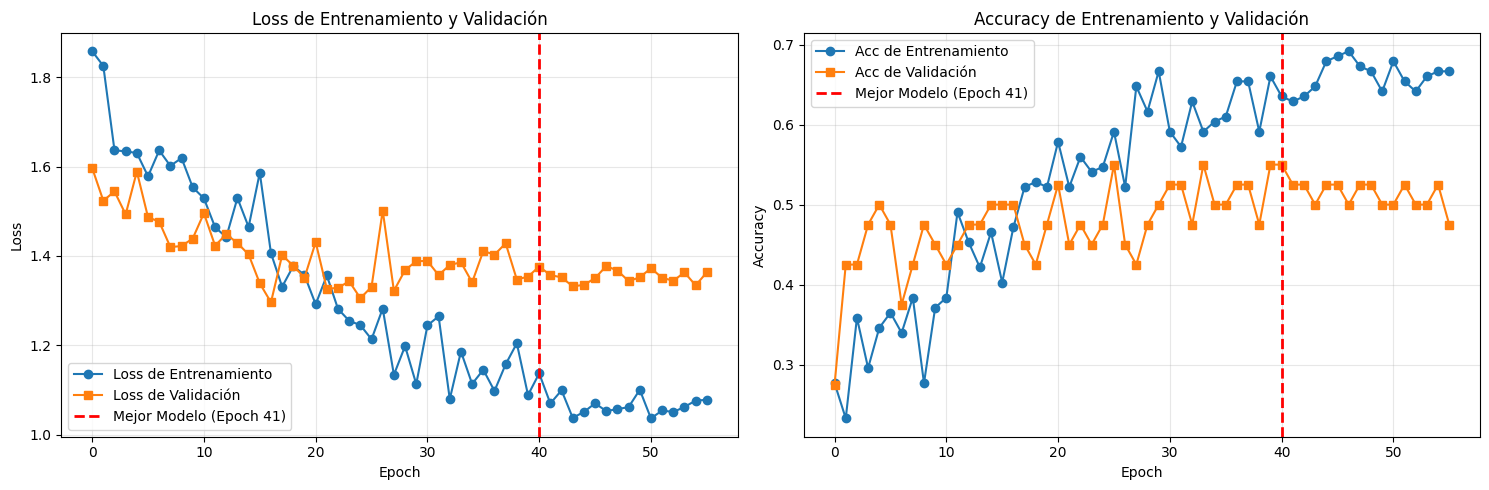

In [23]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Get best epoch for vertical line
best_epoch = checkpoint['epoch']

# Loss plot
ax1.plot(history['train_loss'], label='Loss de Entrenamiento', marker='o')
ax1.plot(history['val_loss'], label='Loss de Validación', marker='s')
ax1.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Mejor Modelo (Epoch {best_epoch + 1})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss de Entrenamiento y Validación')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Acc de Entrenamiento', marker='o')
ax2.plot(history['val_acc'], label='Acc de Validación', marker='s')
ax2.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Mejor Modelo (Epoch {best_epoch + 1})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy de Entrenamiento y Validación')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

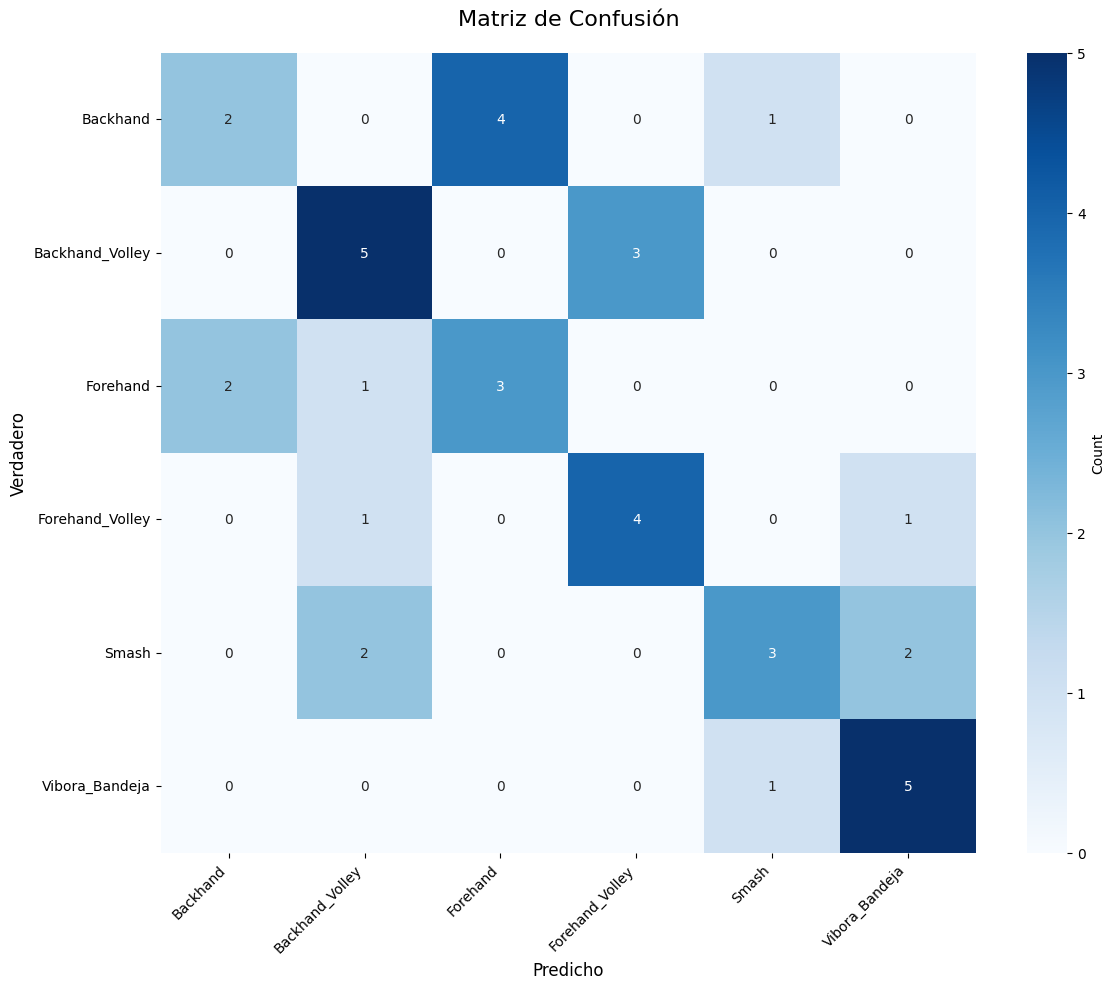

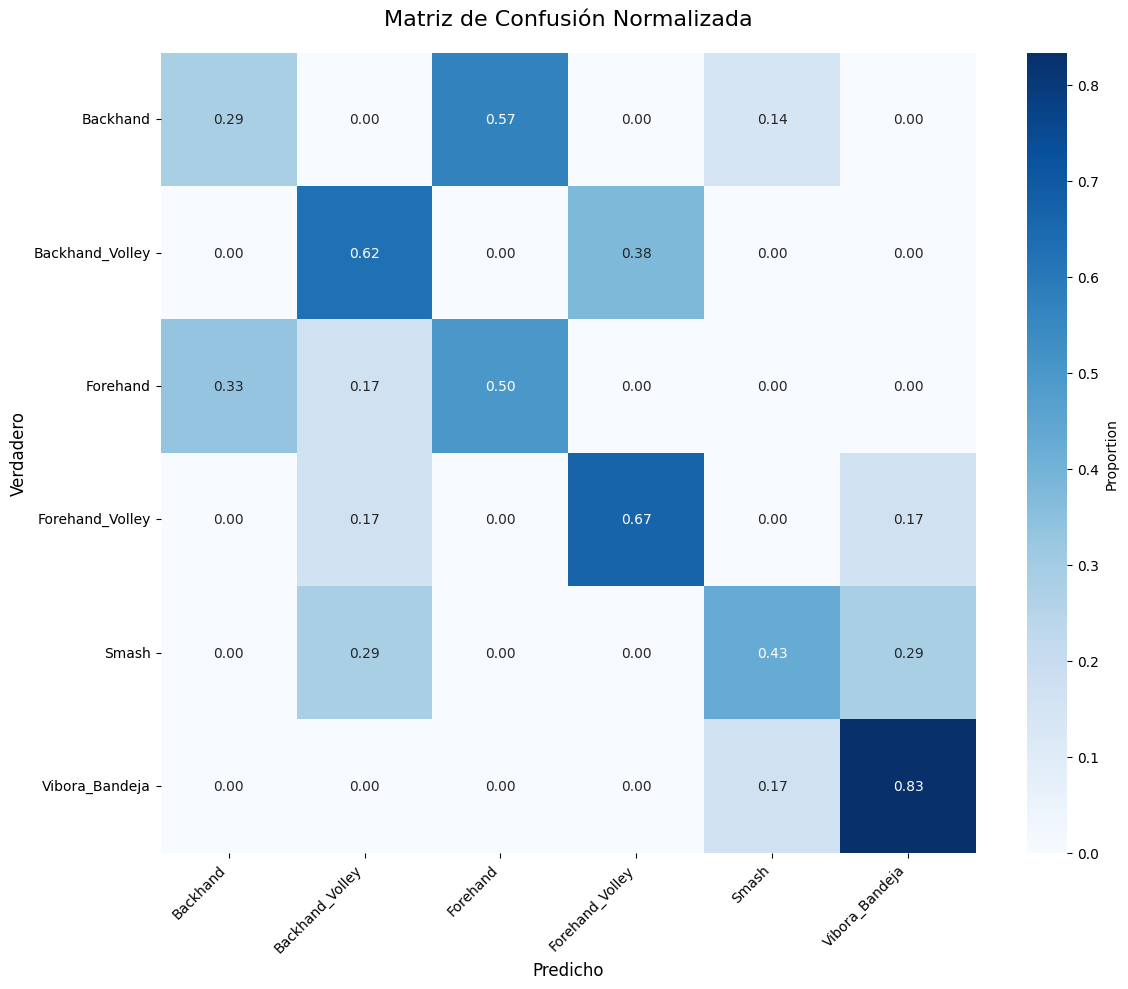

In [24]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=val_dataset.labels,
            yticklabels=val_dataset.labels,
            cbar_kws={'label': 'Count'})
plt.title('Matriz de Confusión', fontsize=16, pad=20)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Verdadero', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=val_dataset.labels,
            yticklabels=val_dataset.labels,
            cbar_kws={'label': 'Proportion'})
plt.title('Matriz de Confusión Normalizada', fontsize=16, pad=20)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Verdadero', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

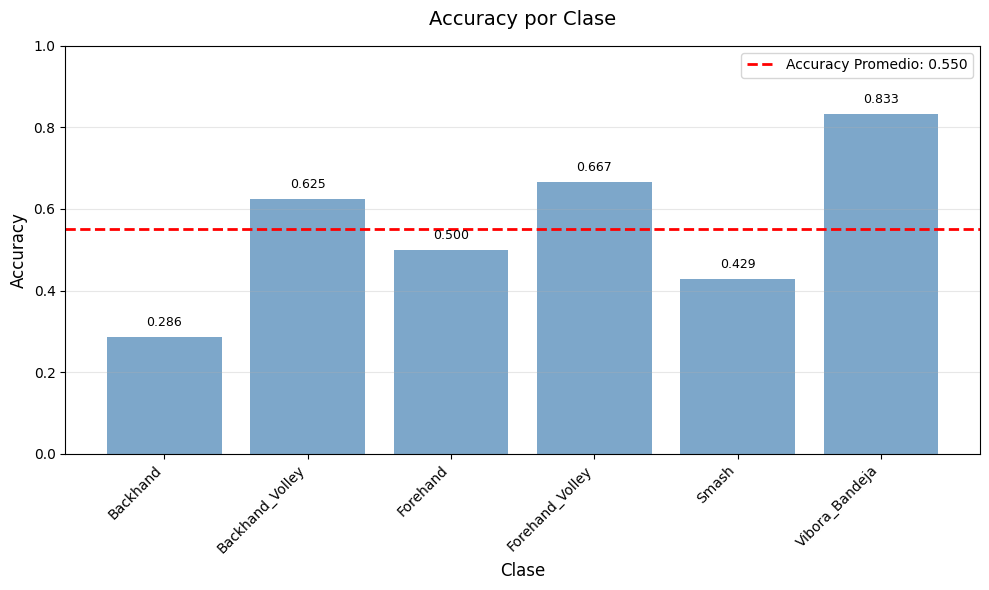


Per-class accuracy:
  Backhand            : 0.2857
  Backhand_Volley     : 0.6250
  Forehand            : 0.5000
  Forehand_Volley     : 0.6667
  Smash               : 0.4286
  Vibora_Bandeja      : 0.8333


In [25]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(val_dataset.labels)), per_class_acc, color='steelblue', alpha=0.7)
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy por Clase', fontsize=14, pad=15)
plt.xticks(range(len(val_dataset.labels)), val_dataset.labels, rotation=45, ha='right')
plt.axhline(y=accuracy, color='red', linestyle='--', label=f'Accuracy Promedio: {accuracy:.3f}', linewidth=2)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, per_class_acc)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nPer-class accuracy:")
for label, acc in zip(val_dataset.labels, per_class_acc):
    print(f"  {label:20s}: {acc:.4f}")

In [26]:
# Save evaluation results
results = {
    'accuracy': float(accuracy),
    'per_class_accuracy': {label: float(acc) for label, acc in zip(val_dataset.labels, per_class_acc)},
    'confusion_matrix': cm.tolist(),
    'labels': val_dataset.labels,
    'num_train_samples': len(train_dataset),
    'num_val_samples': len(val_dataset),
    'best_epoch': int(checkpoint['epoch']),
}

results_path = SKELETON_CACHE / 'evaluation_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nEvaluation results saved to: {results_path}")


Evaluation results saved to: ../artifacts/skeletons_bbox/evaluation_results.json
